In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from ase.db import connect

from asmcmc.measurements import (
    TrajectoryAnalyzer,
    RadialDistributionFunction,
    OrientationalCorrelationFunction,
    NematicOrderParameter,
    HeatCapacity,
    AverageEnthalpy,
    EffectiveSampleSize,
    nematic_q_tensor,
)
from asmcmc.metropolis import BOLTZCONST

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

In [2]:
# --- Grid + replica discovery -------------------------------------------------
base = "../results/low_press_npt_scan"
temps = [10, 50, 100, 150, 200, 250]                 # K
pressures = [5.0e-07, 1.0e-06, 1.5e-06]              # eV/A^3
press_names = {5.0e-07: "5e-07", 1.0e-06: "1e-06", 1.5e-06: "1.5e-06"}
N = 125  # molecules per frame


def replica_paths(temp, pressure):
    """simulation.db for every independent-start replica of a (T, P) point."""
    pt = f"{base}/T{temp}_P{press_names[pressure]}"
    return sorted(glob.glob(f"{pt}/*/simulation.db"))


# sanity: replica count per point (expect 2 everywhere)
for P in pressures:
    counts = {T: len(replica_paths(T, P)) for T in temps}
    print(f"P = {press_names[P]:>8}  replicas/T = {counts}")

P =    5e-07  replicas/T = {10: 2, 50: 2, 100: 2, 150: 2, 200: 2, 250: 2}
P =    1e-06  replicas/T = {10: 2, 50: 2, 100: 2, 150: 2, 200: 2, 250: 2}
P =  1.5e-06  replicas/T = {10: 2, 50: 2, 100: 2, 150: 2, 200: 2, 250: 2}


In [3]:
# --- Minimum-image cutoff r_max ----------------------------------------------
# RDF / OCF are only valid out to half the SHORTEST box edge (the columnar start 
# leaves the column axis longer).
min_half_box = np.inf
for P in pressures:
    for T in temps:
        for path in replica_paths(T, P):
            with connect(path) as db:
                for row in db.select():
                    L = np.linalg.norm(np.array(row.cell), axis=1).min()
                    min_half_box = min(min_half_box, L / 2.0)

r_max = float(min_half_box)
rdf_bins = int(round(r_max / 0.05))   # ~0.05 A: resolve split crystalline peaks
ocf_bins = int(round(r_max / 0.1))    # ~0.1 A: coarser so each shell pools pairs
print(f"r_max = {r_max:.3f} A   (rdf_bins={rdf_bins}, ocf_bins={ocf_bins})")

r_max = 13.088 A   (rdf_bins=262, ocf_bins=131)


In [6]:
# --- Heavy step: analyse every replica of every point ------------------------
# First run is ~150 min; results are cached per replica in an
# `analysis.pkl` file next to each simulation.db, so re-running this cell (or
# restarting the kernel) reloads instantly.  The cache is keyed on the binning
# params -- change r_max / *_bins and stale sidecars are recomputed automatically.
# Set RECOMPUTE = True to force a full re-analysis.
import os
import pickle

RECOMPUTE = False
CACHE_KEY = {"r_max": round(r_max, 6), "rdf_bins": rdf_bins, "ocf_bins": ocf_bins}


def analyze(path, temp, pressure):
    a = TrajectoryAnalyzer(path)
    a.add_measurement("rdf", RadialDistributionFunction(r_max=r_max, num_bins=rdf_bins))
    a.add_measurement("ocf", OrientationalCorrelationFunction(r_max=r_max, num_bins=ocf_bins))
    a.add_measurement("nop", NematicOrderParameter())
    a.add_measurement("c_p", HeatCapacity(temp, N, pressure=pressure))
    a.add_measurement("enthalpy", AverageEnthalpy(pressure=pressure))
    # within-run autocorrelation-aware SEMs for the LINEAR scalars
    a.add_measurement("ess_H", EffectiveSampleSize(
        lambda f, sd, ad: sd["total_energy"] + pressure * f.get_volume()))
    a.add_measurement("ess_S", EffectiveSampleSize(
        lambda f, sd, ad: float(np.linalg.eigvalsh(nematic_q_tensor(ad["or_vec"]))[-1])))
    a.add_measurement("ess_vol", EffectiveSampleSize("vol"))
    return a.run_analysis(progress=True)


def analyze_cached(path, temp, pressure):
    """analyze(), but persist the result in a sidecar next to the db and reuse it
    on later runs when the binning params still match."""
    cache = os.path.join(os.path.dirname(path), "analysis.pkl")
    if not RECOMPUTE and os.path.exists(cache):
        with open(cache, "rb") as fh:
            blob = pickle.load(fh)
        if blob.get("key") == CACHE_KEY:
            return blob["result"]
    result = analyze(path, temp, pressure)
    with open(cache, "wb") as fh:
        pickle.dump({"key": CACHE_KEY, "result": result}, fh)
    return result


results = {}  # (T, P) -> [per-replica result dict, ...]
for P in pressures:
    for T in temps:
        paths = replica_paths(T, P)
        results[(T, P)] = [analyze_cached(p, T, P) for p in paths]
        print(f"done  T{T}_P{press_names[P]}  ({len(paths)} replicas)")

done  T10_P5e-07  (2 replicas)
done  T50_P5e-07  (2 replicas)
done  T100_P5e-07  (2 replicas)
done  T150_P5e-07  (2 replicas)
done  T200_P5e-07  (2 replicas)
done  T250_P5e-07  (2 replicas)
done  T10_P1e-06  (2 replicas)
done  T50_P1e-06  (2 replicas)
done  T100_P1e-06  (2 replicas)
done  T150_P1e-06  (2 replicas)
done  T200_P1e-06  (2 replicas)
done  T250_P1e-06  (2 replicas)
done  T10_P1.5e-06  (2 replicas)
done  T50_P1.5e-06  (2 replicas)
done  T100_P1.5e-06  (2 replicas)
done  T150_P1.5e-06  (2 replicas)
done  T200_P1.5e-06  (2 replicas)
done  T250_P1.5e-06  (2 replicas)


In [5]:
def get_trajectories(temp, pressure):
    paths = replica_paths(temp, pressure)
    trajectories = dict()
    rows = dict()
    for n, path in enumerate(paths):
        with connect(path) as db:
            trajectories[n] = [row.toatoms() for row in db.select()]
            rows[n] = [row for row in db.select()]
    return trajectories, rows

In [36]:
BAD_PAIRS = [(50, 1.5e-06), (50, 1e-06), (50, 5e-07), (100, 1.5e-06), ]

In [22]:
results[(10, 5e-07)][0].keys()

dict_keys(['rdf', 'ocf', 'nop', 'c_p', 'enthalpy', 'ess_H', 'ess_S', 'ess_vol'])

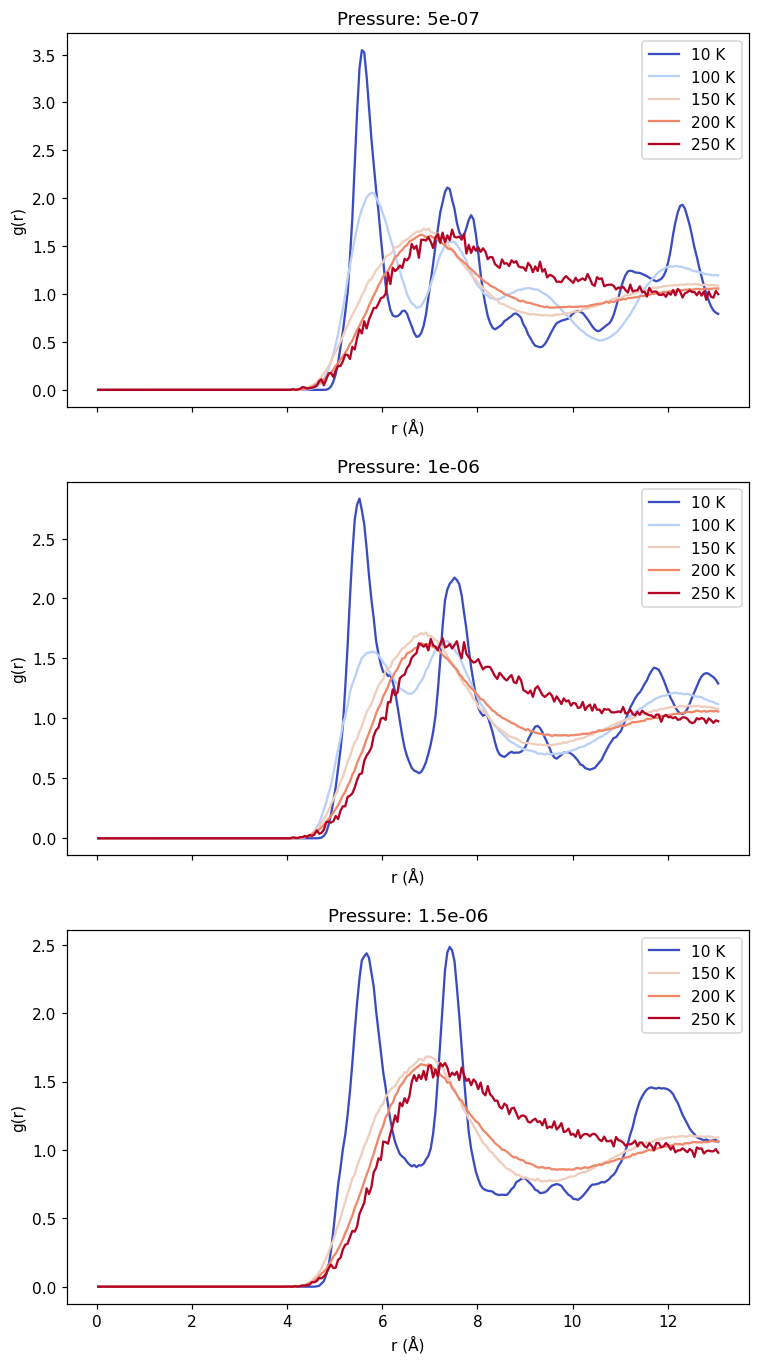

In [37]:
T_CMAP = plt.cm.coolwarm
T_NORM = Normalize(min(temps), max(temps))

fig, axes = plt.subplots(nrows=len(pressures), sharex=True, figsize=(8, 5 * len(pressures)))

for i, press in enumerate(pressures):
    for temp in temps:
        if (temp, press) in BAD_PAIRS:
            continue
        x = results[(temp, press)][0]["rdf"]["r"]
        y1 = results[(temp, press)][0]["rdf"]["g_r"]
        y2 = results[(temp, press)][1]["rdf"]["g_r"]
        y = (y1 + y2) / 2
        axes[i].plot(x, y, color=T_CMAP(T_NORM(temp)), label=f"{temp} K")
    axes[i].set_ylabel("g(r)")
    axes[i].set_xlabel("r (Å)")
    axes[i].set_title(f"Pressure: {press}")
    axes[i].legend()

plt.show()

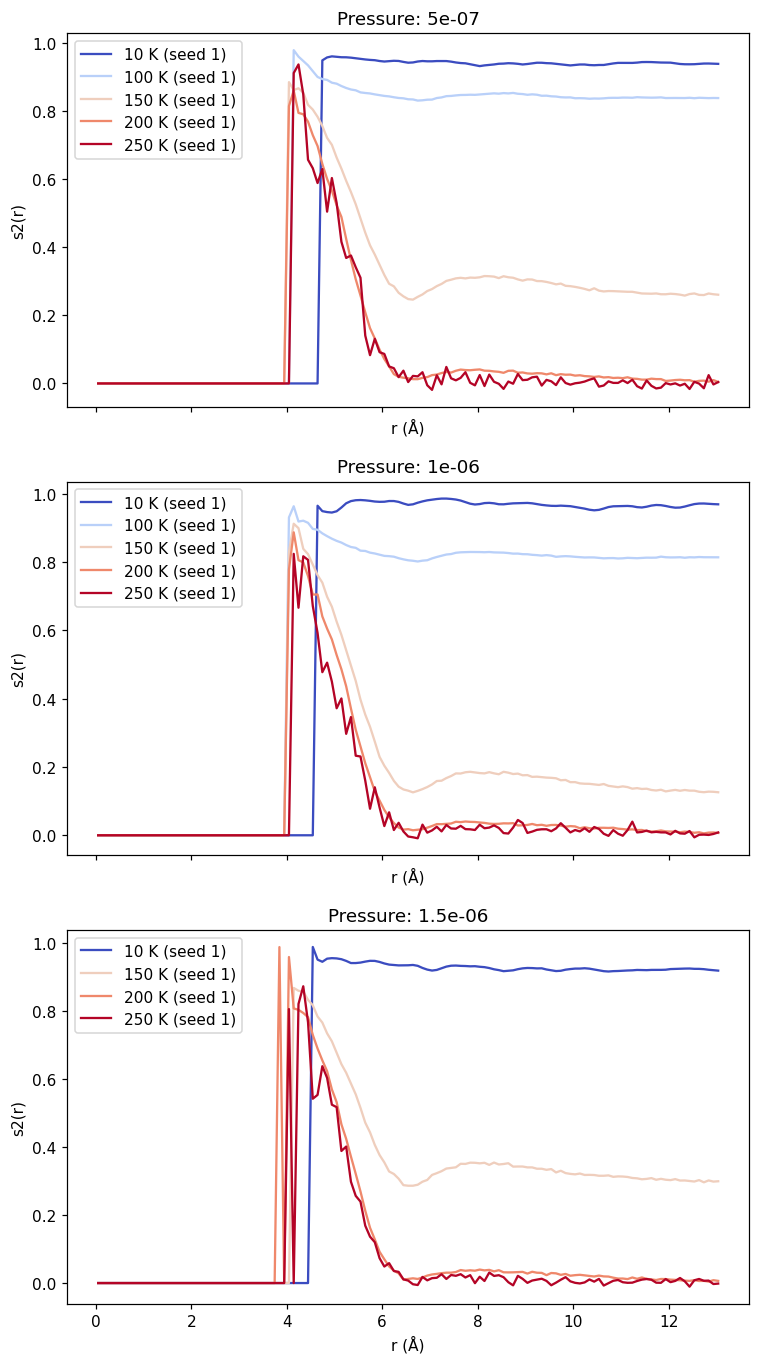

In [41]:
T_CMAP = plt.cm.coolwarm
T_NORM = Normalize(min(temps), max(temps))

fig, axes = plt.subplots(nrows=len(pressures), sharex=True, figsize=(8, 5 * len(pressures)))

for i, press in enumerate(pressures):
    for temp in temps:
        if (temp, press) in BAD_PAIRS:
            continue
        x = results[(temp, press)][0]["ocf"]["r"]
        y1 = results[(temp, press)][0]["ocf"]["s2_r"]
        y2 = results[(temp, press)][1]["ocf"]["s2_r"]
        axes[i].plot(x, y1, color=T_CMAP(T_NORM(temp)), label=f"{temp} K (seed 1)")
        # axes[i].plot(x, y2, color=T_CMAP(T_NORM(temp)), label=f"{temp} K (seed 2)")
    axes[i].set_ylabel("s2(r)")
    axes[i].set_xlabel("r (Å)")
    axes[i].set_title(f"Pressure: {press}")
    axes[i].legend()

plt.show()

In [38]:
results[(10, 5e-07)][0]["ocf"].keys()

dict_keys(['r', 's2_r'])